# Are archived forecasts ready for evaluation?
**Russlan Ramdowar | Future Edge Group**

## tl;dr
This frozen archive contains **746 forecast records for 373 assets**, with one 1-year and one 5-year record per asset. All six selected provenance fields are populated and record IDs are unique. Every row is explicitly **unevaluated**, and every forecast horizon is still unresolved at the fixed **5 October 2026** audit date.

These checks support using the file as an inspectable research archive. They do not support calling it a performance benchmark. The publication/retrieval cutoff for each underlying source is not present in these exported fields, so this notebook cannot establish absence of look-ahead bias.

## Context & Methods
I use three gates when reviewing forecast evidence: identifiable records, a testable time interval, and a completed outcome with an evaluation rule. This notebook makes those gates reproducible on a public iPulse AI snapshot. It measures archive readiness, not investment performance.

### Key Assumptions
- Audit date is fixed at 2026-10-05; rerunning later does not silently change the conclusion.
- Horizon endpoints are **calendar anniversaries of the documented forecast anchor end date**. They are audit proxies, not verified exchange-session settlement dates.
- An elapsed horizon would still require outcome prices, corporate-action treatment and an explicit evaluation rule. It would not by itself imply a completed evaluation.
- Advisor/persona/voice counts do not establish independent underlying models.
- The archive spans equities, cryptocurrencies, indices, forex and commodities; the population is not equities only.

**Source and affiliation:** I founded Future Edge Group, which develops [iPulse AI](https://ipulseai.com), an Open Agentic Investment Research Platform, and [Forecast Library](https://forecastlibrary.com). The source dataset is first-party and released under CC BY 4.0. This is research methodology, not a buy/sell recommendation or a realized-return study.

## Data
The input is the immutable Batch 6 snapshot `ipulse-consensus-batch6-2026-07-05-v2.5`, with 746 rows and 38 columns. The notebook pins both a repository commit and the file SHA-256. It downloads only this small public Parquet file if the local cached copy is absent.

[Dataset card](https://huggingface.co/datasets/future-edge-group/ipulse-ai-historical-consensus-snapshots) · [Methodology](https://huggingface.co/datasets/future-edge-group/ipulse-ai-historical-consensus-snapshots/blob/main/methodology/consensus-snapshot-methodology.md) · [Six-field audit article](https://dev.to/futureedgegroup/audit-your-ai-forecast-dataset-before-calling-it-a-benchmark-29f)

Requirements: Python 3 with pandas, pyarrow, matplotlib and IPython, all available in the standard Kaggle CPU image. Internet must be enabled for the first uncached download. No API key, account token or private data is needed.

In [1]:
from pathlib import Path
from urllib.request import urlopen
import hashlib, json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

AUDIT_DATE = pd.Timestamp('2026-10-05')
DATASET_ID = 'future-edge-group/ipulse-ai-historical-consensus-snapshots'
COMMIT = 'fb81857a92504664604b14150f788db200998454'
EXPECTED_SHA256 = '7361482200e068969ae539ae78794441f62cc32c047494dda6ffb7aaed3db9e9'
INPUT_URL = f'https://huggingface.co/datasets/{DATASET_ID}/resolve/{COMMIT}/data/snapshots/2026-07-05.parquet'
CACHE = Path('forecast-snapshot.parquet')
plt.rcParams.update({'figure.figsize': (9, 4.5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
if not CACHE.exists():
    with urlopen(INPUT_URL, timeout=60) as response:
        CACHE.write_bytes(response.read())
actual_sha256 = hashlib.sha256(CACHE.read_bytes()).hexdigest()
assert actual_sha256 == EXPECTED_SHA256, 'Unexpected source bytes: stop and review the input'
forecasts = pd.read_parquet(CACHE)
assert len(forecasts) == 746 and forecasts.shape[1] == 38
assert forecasts.snapshot_id.nunique() == 1
print(f'Verified source: {len(forecasts):,} records, {forecasts.asset_symbol.nunique():,} assets')
print(f'SHA-256: {actual_sha256}')

Verified source: 746 records, 373 assets
SHA-256: 7361482200e068969ae539ae78794441f62cc32c047494dda6ffb7aaed3db9e9


## Results
### 1. Does each asset have a complete horizon pair?
The natural grain is one asset-symbol/horizon pair. A row count alone can hide duplicates or missing counterpart horizons.

,Forecast records
forecast_horizon,
1y,373
5y,373


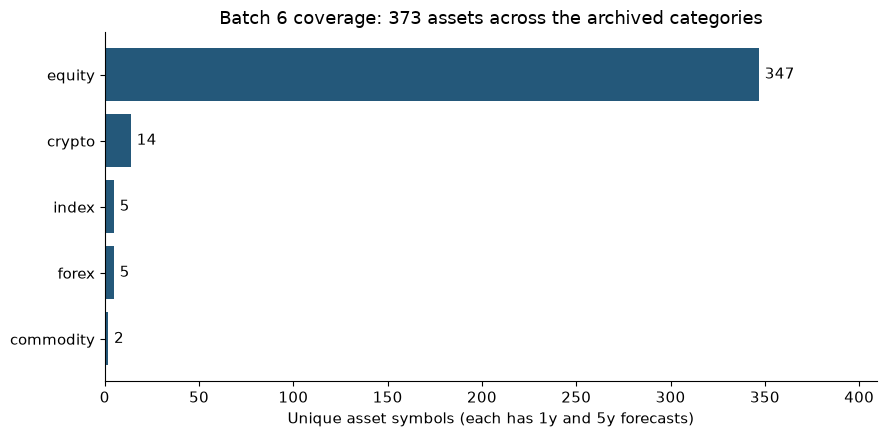

In [2]:
assert forecasts.record_id.is_unique
assert not forecasts.duplicated(['asset_symbol', 'forecast_horizon']).any()
pair_counts = forecasts.pivot_table(index='asset_symbol', columns='forecast_horizon',
                                   values='record_id', aggfunc='count', fill_value=0)
assert set(pair_counts.columns) == {'1y', '5y'}
assert (pair_counts == 1).all().all()
category_counts = (forecasts.drop_duplicates('asset_symbol')
                   .groupby('asset_category').size().sort_values())
display(pd.DataFrame({'Forecast records': forecasts.groupby('forecast_horizon').size()}))
fig, ax = plt.subplots()
bars = ax.barh(category_counts.index, category_counts.values, color='#24587a')
ax.bar_label(bars, padding=4)
ax.set_xlim(0, category_counts.max()*1.18)
ax.set_xlabel('Unique asset symbols (each has 1y and 5y forecasts)')
ax.set_title('Batch 6 coverage: 373 assets across the archived categories')
fig.tight_layout()
fig.savefig('asset-coverage.png', dpi=150)
plt.show()

Every asset has exactly one record for each horizon. The chart counts assets once, rather than double-counting the two horizons. This is coverage of the archived population, not a representative market sample.

In [3]:
provenance_fields = ['record_id', 'snapshot_id', 'forecast_horizon',
                     'scoring_completed_at_utc', 'source_algorithm_version', 'record_checksum']
missing = forecasts[provenance_fields].isna() | forecasts[provenance_fields].eq('')
display(pd.DataFrame({'Missing or blank records': missing.sum(),
                      'Checked records': len(forecasts)}))
assert missing.sum().sum() == 0

,Missing or blank records,Checked records
record_id,0,746
snapshot_id,0,746
forecast_horizon,0,746
scoring_completed_at_utc,0,746
source_algorithm_version,0,746
record_checksum,0,746


All six selected fields are populated. A nonblank checksum is not proof that the forecast was accurate, signed, published before a decision, or derived only from information available at that time.

### 2. Are the forecast horizons complete?
Evaluation must separate a still-open forecast from an observed outcome. Use the documented anchor and the fixed audit date rather than treating the scoring timestamp as the start of the return interval.

,records,earliest_endpoint,latest_endpoint,elapsed,unresolved
forecast_horizon,,,,,
1y,373,2027-07-02,2027-07-05,0,373
5y,373,2031-07-02,2031-07-05,0,373


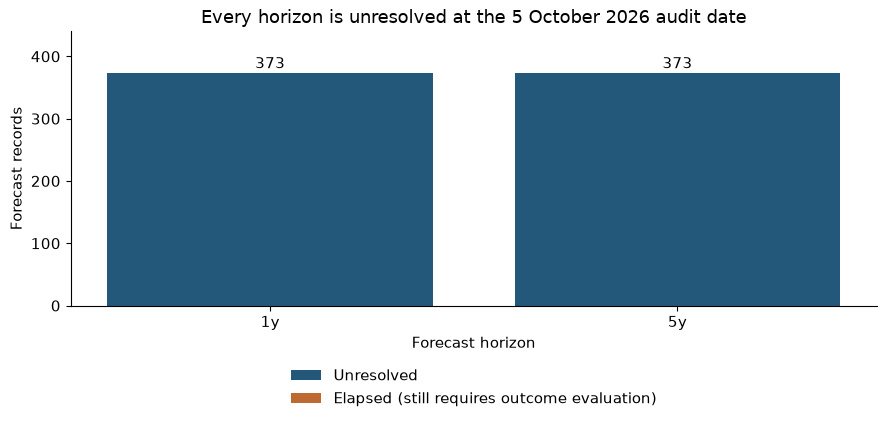

In [4]:
anchor_start = pd.to_datetime(forecasts.forecast_anchor_start_date)
anchor_end = pd.to_datetime(forecasts.forecast_anchor_end_date)
assert (anchor_start <= anchor_end).all()
assert set(forecasts.forecast_horizon) == {'1y', '5y'}
proxy_endpoint = pd.Series([
    date + pd.DateOffset(years={'1y': 1, '5y': 5}[horizon])
    for date, horizon in zip(anchor_end, forecasts.forecast_horizon)
], index=forecasts.index)
resolved = proxy_endpoint <= AUDIT_DATE
evaluation = forecasts.evaluation_methodology_version.fillna('MISSING')
assert evaluation.eq('not_applicable_not_evaluated').all()
maturity = forecasts[['forecast_horizon']].assign(
    proxy_endpoint=proxy_endpoint, elapsed_by_audit=resolved)
summary = maturity.groupby('forecast_horizon').agg(
    records=('proxy_endpoint','size'), earliest_endpoint=('proxy_endpoint','min'),
    latest_endpoint=('proxy_endpoint','max'), elapsed=('elapsed_by_audit','sum'))
summary['unresolved'] = summary.records - summary.elapsed
display(summary)
fig, ax = plt.subplots()
ax.bar(summary.index, summary.unresolved, color='#24587a', label='Unresolved')
ax.bar(summary.index, summary.elapsed, bottom=summary.unresolved,
       color='#bc6a32', label='Elapsed (still requires outcome evaluation)')
for x, y in enumerate(summary.unresolved):
    ax.text(x, y+8, str(int(y)), ha='center')
ax.set_ylim(0, max(summary.records)*1.18)
ax.set_ylabel('Forecast records')
ax.set_xlabel('Forecast horizon')
ax.set_title('Every horizon is unresolved at the 5 October 2026 audit date')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)
fig.tight_layout()
fig.savefig('horizon-maturity.png', dpi=150)
plt.show()
assert resolved.sum() == 0

Both horizons contain 373 unresolved records. All 746 rows are explicitly unevaluated. Annualized expected-return fields are forecasts; they are not measured returns. This file cannot be used to report a realized forecasting hit rate or profitable track record.

### 3. Does a timestamp prove the information cutoff?
The archive records forecast anchors and scoring completion. It does not export the publication and retrieval times of every underlying filing or other source. The lag below describes processing chronology only.

In [5]:
scored_at = pd.to_datetime(forecasts.scoring_completed_at_utc, utc=True)
anchor_midnight = anchor_end.dt.tz_localize('UTC')
lag_days = (scored_at-anchor_midnight).dt.total_seconds()/86400
chronology = pd.DataFrame({'Minimum': [lag_days.min()], 'Median': [lag_days.median()],
                          'Maximum': [lag_days.max()]}, index=['Scoring lag from anchor end (days)'])
display(chronology.round(2))
model_counts = forecasts.model_count.value_counts(dropna=False).sort_index()
display(pd.DataFrame({'Records': model_counts}).rename_axis('Underlying model count'))
assert forecasts.model_count.eq(1).all()

,Minimum,Median,Maximum
Scoring lag from anchor end (days),3.89,6.89,6.89


,Records
Underlying model count,
1,746


Scoring completion after an anchor is not, by itself, evidence of leakage or evidence against leakage. To test availability at the intended decision time, retain the actual source publication time, retrieval time, decision cutoff and original output. Here, every record reports one underlying model even when several advisor perspectives are present. Perspective diversity and model independence are different claims.

### 4. A small control for annual versus cumulative returns
This example is hypothetical and separate from the archived observations. It shows why an average annual forecast and an average terminal-value forecast are different estimands when nonlinear compounding is involved.

In [6]:
annual_forecasts = pd.Series([0.0, 0.20])
years = 5
initial_value = 100.0
mean_terminal_value = (initial_value*(1+annual_forecasts)**years).mean()
terminal_value_of_mean = initial_value*(1+annual_forecasts.mean())**years
implied_cagr = (mean_terminal_value/initial_value)**(1/years)-1
controls = pd.DataFrame({'Terminal value (start=100)': [mean_terminal_value, terminal_value_of_mean],
                         'Cumulative return (%)': [(mean_terminal_value/100-1)*100,
                                                   (terminal_value_of_mean/100-1)*100]},
                        index=['Mean of compounded scenarios', 'Compound the mean annual rate'])
display(controls.round(2))
assert abs(mean_terminal_value-174.416) < 1e-9
assert abs(terminal_value_of_mean-161.051) < 1e-9
print(f'Gap: {(mean_terminal_value-terminal_value_of_mean):.3f} cumulative percentage points')
print(f'CAGR implied by mean endpoint: {implied_cagr*100:.2f}%')

,Terminal value (start=100),Cumulative return (%)
Mean of compounded scenarios,174.42,74.42
Compound the mean annual rate,161.05,61.05


Gap: 13.365 cumulative percentage points
CAGR implied by mean endpoint: 11.77%


The two equally weighted scenarios imply a **74.42%** mean cumulative return; compounding their **10%** mean annual rate implies **61.05%**. The **13.365 percentage-point** gap is a mathematical effect, not evidence of investment alpha. The annual equivalent of the mean endpoint is **11.77%**.

[Detailed return-aggregation research](https://ipulseai.com/concepts/how-to-compare-ai-stock-forecasts-cagr-and-total-return) examines a **separate 766-record equity cohort**. Do not combine that cohort's counts with this 746-record multi-asset archive.

## Takeaways
1. **Archive completeness passes the selected checks:** 746 unique IDs, 373 complete horizon pairs and no missing values in six specified provenance fields.
2. **Performance evaluation is not available:** all rows are marked unevaluated and all proxy horizon endpoints remain in the future at the fixed audit date.
3. **Information availability needs more evidence:** record-level source publication/retrieval cutoffs are absent from this export, and one underlying model should not be described as several independent models.
4. **Define the return quantity before comparing forecasts:** annual and cumulative aggregation need not produce the same result.

To turn an archive into an evaluation dataset, define the intended decision time, retain source cutoffs and original outputs, join outcomes only after the relevant horizon, handle corporate actions and currency, specify a benchmark and rule, and report missing or immature cases rather than assigning zero returns.

This notebook deliberately makes no accuracy, calibration or trading-performance claim.

In [7]:
audit = {'snapshot_id': forecasts.snapshot_id.iloc[0], 'audit_date': str(AUDIT_DATE.date()),
         'input_sha256': actual_sha256, 'input_commit': COMMIT,
         'records': len(forecasts), 'assets': len(pair_counts),
         'missing_selected_provenance_fields': int(missing.sum().sum()),
         'unresolved_records': int((~resolved).sum()),
         'unevaluated_records': int(evaluation.eq('not_applicable_not_evaluated').sum()),
         'underlying_model_counts': {str(k): int(v) for k,v in model_counts.items()},
         'source_cutoff_test': 'not possible from exported fields'}
Path('readiness-audit.json').write_text(json.dumps(audit, indent=2))
print('Saved readiness-audit.json and the two figures for inspection.')

Saved readiness-audit.json and the two figures for inspection.
